# Clustering Comparison: DBSCAN vs. K-Means

In this notebook, we explore how different clustering algorithms perform on a non-linearly separable dataset (the 'Moons' dataset). We will walk through:
1. Data Generation
2. Data Scaling
3. Density-Based Clustering (DBSCAN)
4. Centroid-Based Clustering (K-Means)

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

## 1. Data Generation
We start by creating a synthetic 'moons' dataset. This dataset is famous in machine learning because the two classes are shaped like interlaced crescents, making them difficult to separate using simple linear methods.

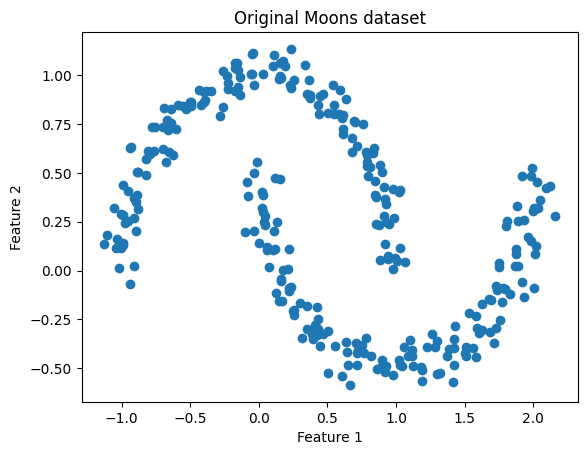

In [2]:
X, y = make_moons(n_samples=300, noise=0.06, random_state=42)

plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Moons dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 2. Feature Scaling
Clustering algorithms rely on distance metrics (like Euclidean distance). If features have different scales, one feature might dominate the distance calculation. We use `StandardScaler` to ensure our data has a mean of 0 and a standard deviation of 1.

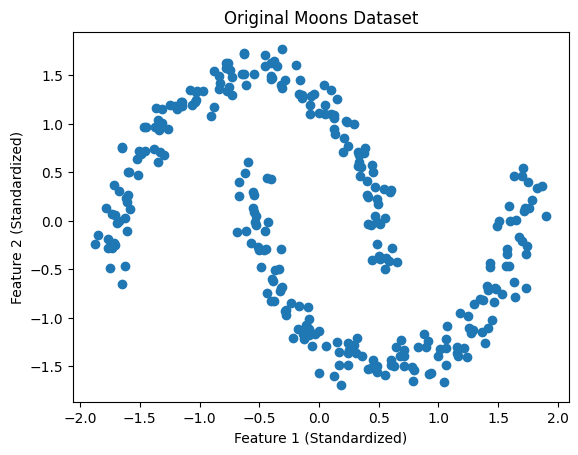

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.title("Original Moons Dataset")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.show()

## 3. Density-Based Spatial Clustering (DBSCAN)
DBSCAN groups points that are closely packed together. It is particularly effective for datasets with complex shapes like our moons, as it doesn't assume clusters are spherical. It also identifies points in low-density regions as outliers (noise).

In [7]:
dbscan = DBSCAN(eps=0.3, min_samples=3)

In [8]:
dbscan.fit(X_scaled)
label_dbscan = dbscan.labels_

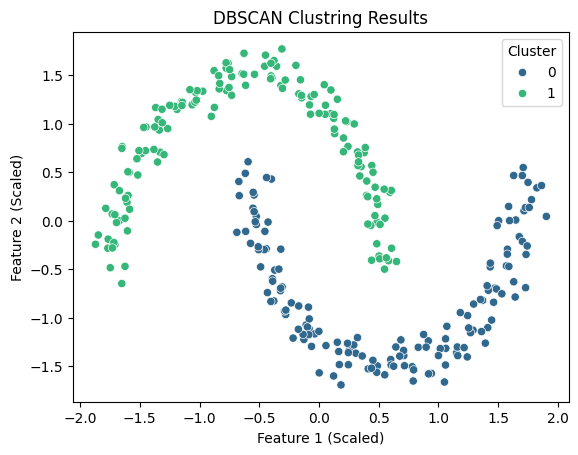

In [9]:
sns.scatterplot(x = X_scaled[:, 0], y = X_scaled[:, 1], hue=label_dbscan, palette='viridis')

plt.title("DBSCAN Clustring Results")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend(title='Cluster')
plt.show()

## 4. K-Means Clustering
Now, let's compare the results with K-Means. K-Means tries to partition the data into $K$ clusters by minimizing the distance between points and their cluster centers (centroids). Note how it struggles with the crescent shapes compared to DBSCAN.

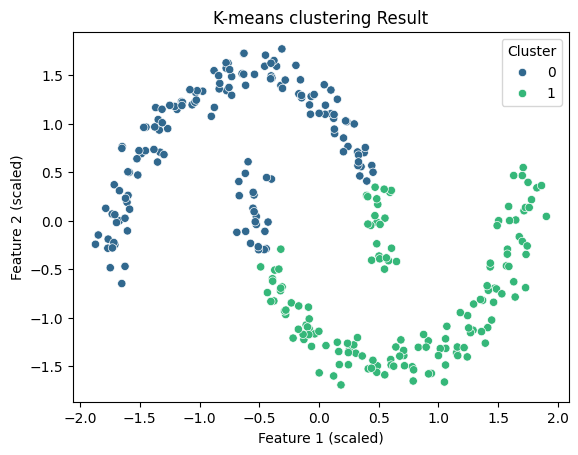

In [11]:
#Implementing K-Means
kmeans = KMeans(
    n_clusters = 2,
    init= "k-means++",
    max_iter=300,
    random_state = 42
)
kmeans.fit(X_scaled)
label_kmeans = kmeans.labels_

sns.scatterplot(x = X_scaled[:, 0], y = X_scaled[:, 1], hue=label_kmeans, palette='viridis')
plt.title("K-means clustering Result")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend(title='Cluster')
plt.show()